## NoteBook Imports

In [4]:
import os
from os import walk
from os.path import join
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager

import nltk

from nltk.stem import PorterStemmer
from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from IPython.display import display 
import seaborn as sns
import pandas as pd

from bs4 import BeautifulSoup # for html tags
from wordcloud import WordCloud
from PIL import Image

from sklearn.model_selection import train_test_split

%matplotlib inline

# Constants

In [9]:
TOKEN_SPAM_PROB_FILE = '2.1 SpamData/03_Testing/prob-spam.txt'
TOKEN_HAM_PROB_FILE = '2.1 SpamData/03_Testing/prob-nonspam.txt'
TOKEN_ALL_PROB_FILE = '2.1 SpamData/03_Testing/prob-all-tokens.txt'

TEST_FEATURE_MATRIX = '2.1 SpamData/03_Testing/test-features.txt'
TEST_TARGET_FILE = '2.1 SpamData/03_Testing/test-target.txt'

VOCAB_SIZE = 2500

## Load the Data

In [10]:
# Features
X_test = np.loadtxt(TEST_FEATURE_MATRIX, delimiter=' ')
# Target
y_test = np.loadtxt(TEST_TARGET_FILE, delimiter=' ')
# Token Probabilities
prob_token_spam = np.loadtxt(TOKEN_SPAM_PROB_FILE, delimiter=' ')
prob_token_ham = np.loadtxt(TOKEN_HAM_PROB_FILE, delimiter=' ')
prob_all_tokens = np.loadtxt(TOKEN_ALL_PROB_FILE, delimiter=' ')

In [11]:
X_test[:5]

array([[0., 0., 1., ..., 0., 0., 0.],
       [6., 1., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 2., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

## Calculating the Joint Probability
## The Dot Product

In [12]:
a = np.array([1, 2, 3])
b = np.array([0, 5, 4])
print('a = ', a)
print('b = ', b)

a =  [1 2 3]
b =  [0 5 4]


In [13]:
a.dot(b)

np.int64(22)

In [14]:
1*0 + 2*5 + 3*4


22

In [15]:
c = np.array([[0, 6], [3, 0], [5, 1]])
print('shape of c is', c.shape)
print(c)

shape of c is (3, 2)
[[0 6]
 [3 0]
 [5 1]]


In [16]:
print(a.dot(c))
print('shape of the dot product is', a.dot(c).shape)

[21  9]
shape of the dot product is (2,)


In [17]:
[1*0 + 2*3 + 3*5, 1*6 + 2*0 + 3*1]


[21, 9]

#### Challenge: Can you figure out the dimensions of the dot product between X_test and prob_token_spam?

In [18]:
X_test.shape


(1724, 2500)

In [19]:
prob_token_spam.shape


(2500,)

In [20]:
print('shape of the dot product is ', X_test.dot(prob_token_spam).shape)


shape of the dot product is  (1724,)


### Set the Prior

#### $$P(Spam\, | \, x) = \frac{P(X \, | Spam) \, P(Spam)}  {P(X)}$$

In [21]:
PROB_SPAM = 0.3116


"Challenge: Do you recall how to take the log of a numpy array? Calculate the log probabilities of the tokens given
that the email was spam. This was stored in prob_token_spam."

## Joint probability in log format

In [22]:
joint_log_spam = X_test.dot(np.log(prob_token_spam) - np.log(prob_all_tokens)) + np.log(PROB_SPAM)

In [23]:
joint_log_spam[:5]

array([22.71411285,  2.16390671, 20.57152924, 17.7542923 , 21.55220765])

Challenge: Calculate the log probability that the emails are non-spam given their tokens. Store the result in a variable called joint_log_ham

#### $$P(ham\, | \, x) = \frac{P(X \, | ham) \, (1-P(spam))}  {P(X)}$$

In [24]:
 joint_log_ham = X_test.dot(np.log(prob_token_ham) - np.log(prob_all_tokens)) + np.log(1-PROB_SPAM)

In [25]:
 joint_log_ham[:5]

array([-60.45048357, -11.00849722, -37.94432796, -59.15134914,
       -54.92815649])

In [26]:
 joint_log_ham.size

1724

# Making Predictions
### Checking for higher joint probability

$$P(spam\, | \, x) \, > \, P(ham \, | \, X)$$
<center>**OR**</center>
<br>
$$P(spam\, | \, x) \, < \, P(ham \, | \, X)$$

Challenge: Can you create the vector of predictions, our $\hat y$ ? Remember that spam emails should have the value 1 (true) and non-spam emails should have the value 0 (false). Store your results in a variable called prediction.

In [27]:
prediction = joint_log_spam > joint_log_ham

In [28]:
prediction[-5:]*1

array([1, 0, 0, 0, 0])

In [29]:
y_test[-5:]

array([0., 0., 0., 0., 0.])

### Simplify

#### $$P(x \, | \, spam) = \, P(spam) = \frac{P(X \, | \, spam) \, P(spam)}  {P(X)}$$

In [30]:
joint_log_spam = X_test.dot(np.log(prob_token_spam)) + np.log(PROB_SPAM)
joint_log_ham = X_test.dot(np.log(prob_token_ham)) + np.log(1-PROB_SPAM)

# Metrics and Evaluation
### Accurary

In [31]:
correct_docs = (y_test == prediction).sum()
print('Docs Classified Correctly', correct_docs)
numdocs_wrong = X_test.shape[0] - correct_docs
print('Docs Classified InCorrectly', numdocs_wrong)

Docs Classified Correctly 1685
Docs Classified InCorrectly 39


In [32]:
# Accuracy 
correct_docs/len(X_test)


np.float64(0.9773781902552204)

In [33]:
fraction_wrong = numdocs_wrong/len(X_test)
print('Fraction classified incorrectly is {:.2%}'.format(fraction_wrong))
print('Accuracy of the Model is {:.2%}'.format(1-fraction_wrong))

Fraction classified incorrectly is 2.26%
Accuracy of the Model is 97.74%


# Visualising the Results 

In [34]:
# Chart Styling Info
yaxis_label = 'P(X | Spam)'
xaxis_label = 'P(X | Nonspam)'

linedata = np.linspace(start=-14000, stop=1, num=1000)

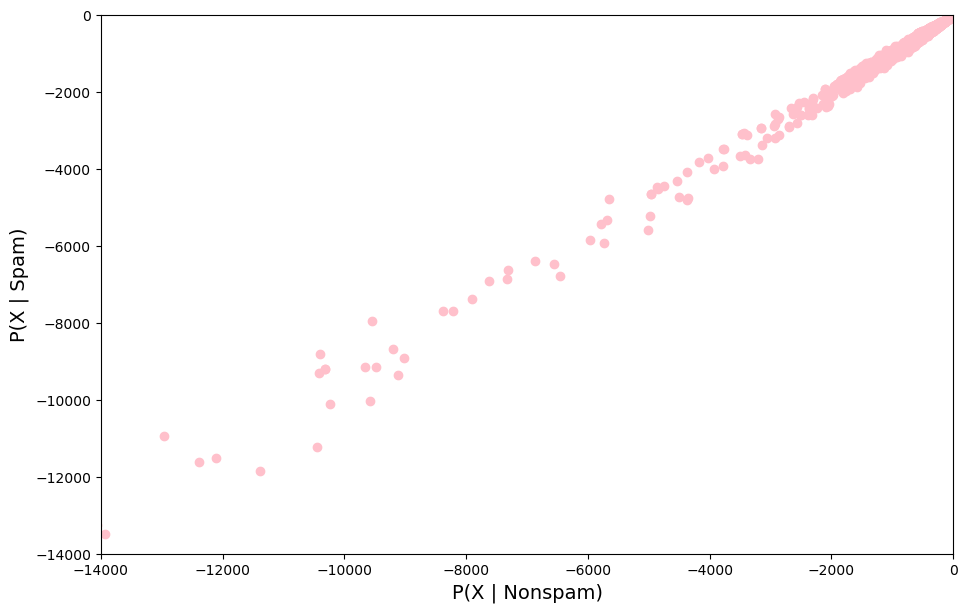

In [35]:

plt.figure(figsize=(11, 7))
plt.xlabel(xaxis_label, fontsize=14)
plt.ylabel(yaxis_label, fontsize=14)

# Set scale
plt.xlim([-14000, 1])
plt.ylim([-14000, 1])

plt.scatter(joint_log_ham, joint_log_spam, color='pink')
plt.show()

## The Decision Boundary

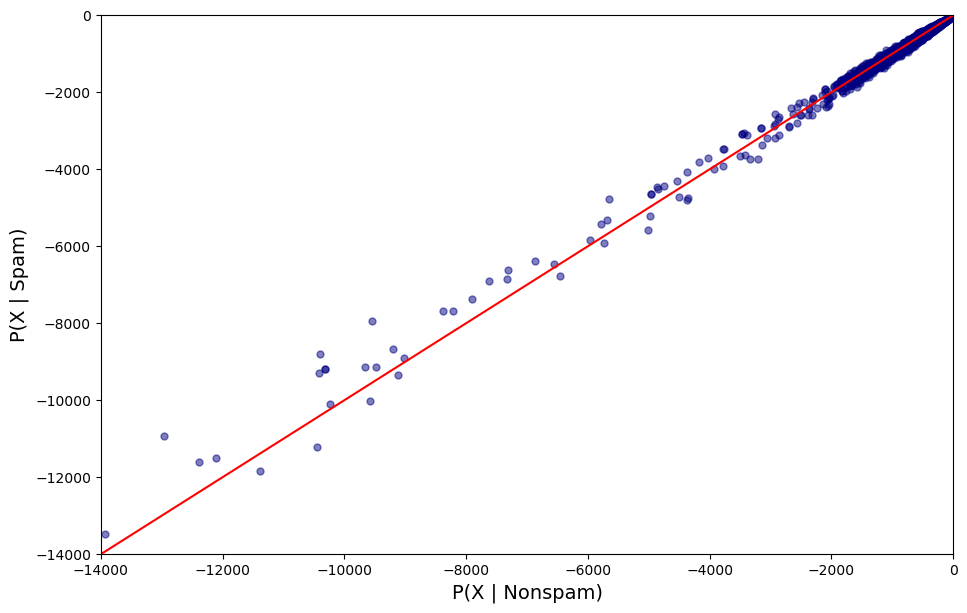

In [36]:
plt.figure(figsize=(11, 7))
plt.xlabel(xaxis_label, fontsize=14)
plt.ylabel(yaxis_label, fontsize=14)

# Set scale
plt.xlim([-14000, 1])
plt.ylim([-14000, 1])

plt.scatter(joint_log_ham, joint_log_spam, color='navy', alpha=0.5, s=25)
plt.plot(linedata, linedata, color='red')
plt.show()

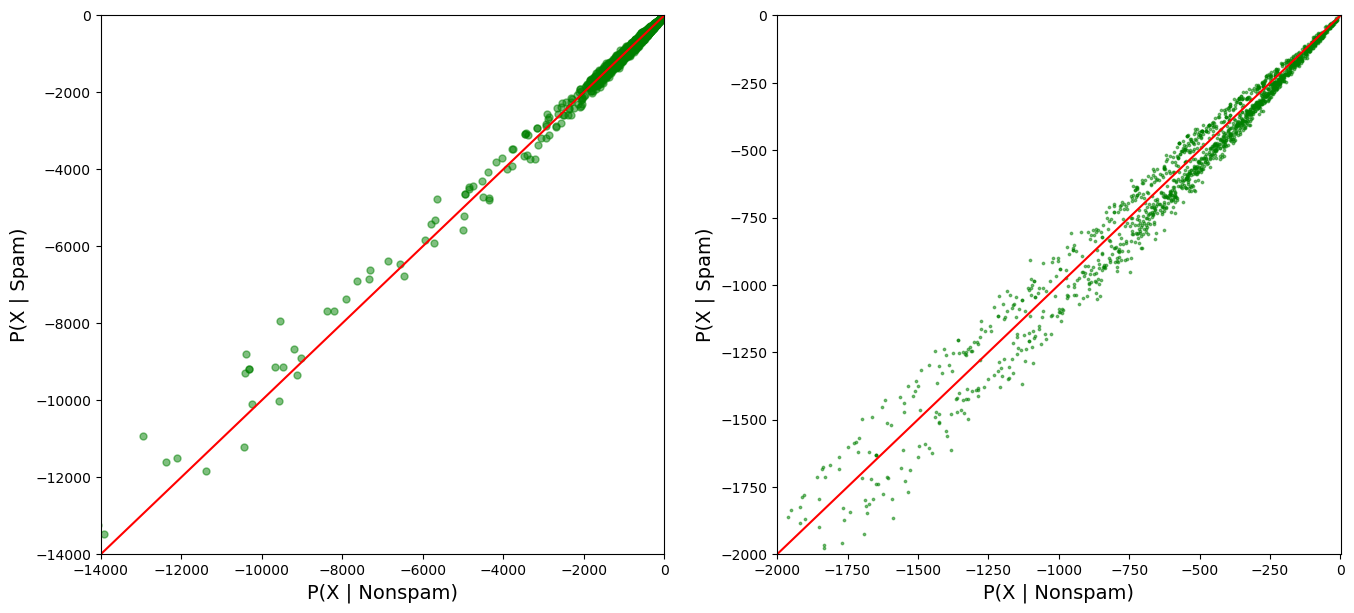

In [37]:
plt.figure(figsize=(16, 7))

# Chart 1
plt.subplot(1,2,1)

plt.xlabel(xaxis_label, fontsize=14)
plt.ylabel(yaxis_label, fontsize=14)

# Set scale
plt.xlim([-14000, 1])
plt.ylim([-14000, 1])

plt.scatter(joint_log_ham, joint_log_spam, color='green', alpha=0.5, s=25)
plt.plot(linedata, linedata, color='red')

# Chart 1
plt.subplot(1,2,2)

plt.xlabel(xaxis_label, fontsize=14)
plt.ylabel(yaxis_label, fontsize=14)

# Set scale
plt.xlim([-2000, 1])
plt.ylim([-2000, 1])

plt.scatter(joint_log_ham, joint_log_spam, color='green', alpha=0.5, s=3)
plt.plot(linedata, linedata, color='red')

plt.show()

In [38]:
#Chart Styling 
sns.set_style('whitegrid')
labels = 'Actual Category'

summary_df = pd.DataFrame({yaxis_label:joint_log_spam, xaxis_label: joint_log_ham, labels:y_test})

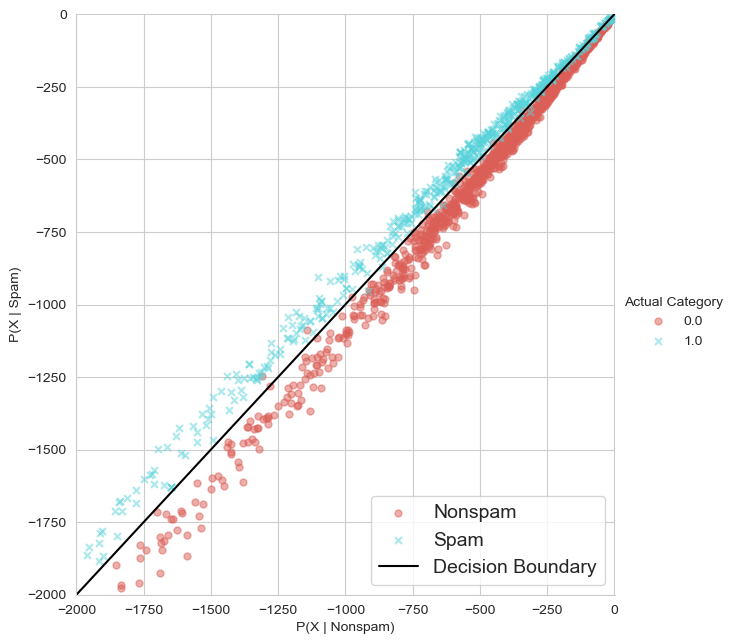

In [39]:
sns.lmplot(x=xaxis_label, y=yaxis_label, data=summary_df, height=6.5, fit_reg=False, 
           scatter_kws={'alpha': 0.5,'s': 25}, hue=labels, markers=['o', 'x'],palette='hls')

plt.xlim([-2000, 1])
plt.ylim([-2000, 1])

plt.plot(linedata, linedata, color='black')

plt.legend(['Nonspam', 'Spam', 'Decision Boundary'], loc='lower right', fontsize=14)
plt.show()

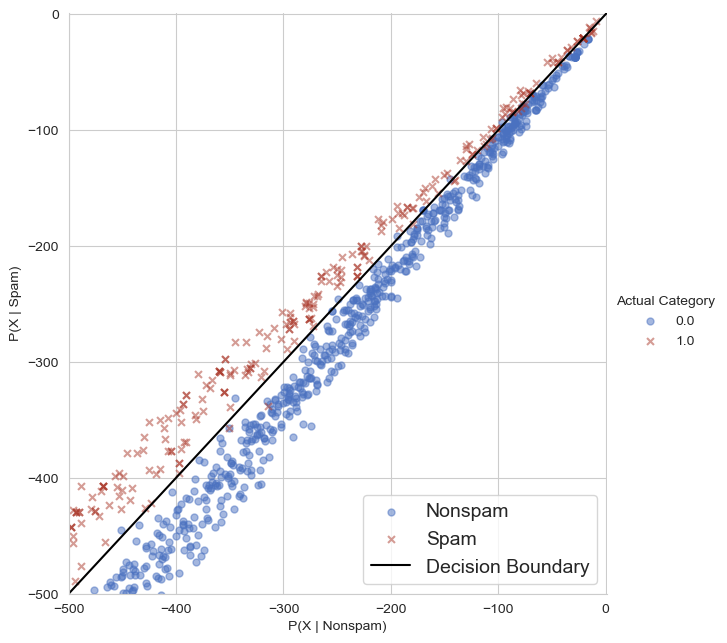

In [40]:
my_colours = ['#4A71C0', '#AB3A2C']
sns.lmplot(x=xaxis_label, y=yaxis_label, data=summary_df, height=6.5, fit_reg=False, 
           scatter_kws={'alpha': 0.5,'s': 25}, hue=labels, markers=['o', 'x'],palette=my_colours)

plt.xlim([-500, 1])
plt.ylim([-500, 1])

plt.plot(linedata, linedata, color='black')

plt.legend(['Nonspam', 'Spam', 'Decision Boundary'], loc='lower right', fontsize=14)
plt.show()

# False Positives and False Negatives

In [41]:
np.unique(prediction, return_counts=True)

(array([False,  True]), array([1136,  588]))

In [42]:
true_pos = (y_test == 1) & (prediction == 1)

In [43]:
true_pos

array([ True,  True,  True, ..., False, False, False])

In [44]:
false_pos = (y_test == 0) & (prediction == 1)
false_pos.sum()

np.int64(19)

In [45]:
false_neg = (y_test == 1) & (prediction == 0)
false_neg.sum()

np.int64(20)

# Recall Score 

In [46]:
recall_score = true_pos.sum() / (true_pos.sum() + false_neg.sum())
print('Recall Score is {:.2%}'.format(recall_score))


Recall Score is 96.60%


# Precsison Score

In [47]:
precision_score = true_pos.sum() / (true_pos.sum() + false_pos.sum())
print('Precision score is {:.3}'.format(precision_score))

Precision score is 0.968


# F-Score or F1 Score 

In [50]:
f1_score = 2 *(precision_score + recall_score ) / (precision_score + recall_score)
print('F score is {:.2}'.format(f1_score))

F score is 2.0


# 

# Testing Done

# Testing Done.
